# 线性回归和优化方法

## 线性回归

### 线性模型
- 把试图预测的目标（比如预测房屋价格）称为标签（label）或目标（target）。
- 预测所依据的自变量（面积和房龄）称为特征（feature）或协变量（covariate）。

给定n维输入x=[x,x2,....xm]T

线性模型有一个n维权重和一个标量偏差w=[wi,W2,...,Wn]T,b

输出是输入的加权和y=w1x1+w2x2+...+wnxn+b

向量版本:y=<w,x>+b

线性模型可以看作是单层神经网络

### 衡量预估质量
实际值与预测值之间的差距

平方损失：1/2 *（预测值-实际值）^2

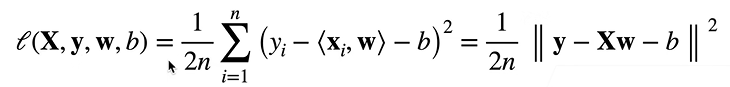

最小化损失函数来学习参数 w,b

因为损失函数是凸函数（像碗），一定有最小值，最优解


最优解：w* = (X⊤X)^-1XTy

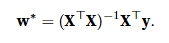

### 代码实现

In [ ]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l
# import os
# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [ ]:
def synthetic_data(w, b, num_examples): #@save
    """⽣成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))   #生成随机数据
    y = torch.matmul(X, w) + b    #矩阵乘法
    y += torch.normal(0, 0.01, y.shape) 
    return X, y.reshape((-1, 1))    #-1自动填充

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [ ]:
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([-0.2665,  2.0426]) 
label: tensor([-3.2855])


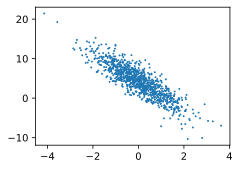

In [ ]:
d2l.set_figsize()

# 绘制：选取 features 的第二列（下标1），并确保数据在 CPU 上转成 numpy
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

In [ ]:
def data_iter(batch_size, features, labels):
#接受输入，返回大小为 batch_size 的小批量
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
        indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]
# 带yield的函数是一个生成器，可循环返回数据。它记住上一次返回时在函数体中的位置。
# #对生成器函数的第二次（或第 n 次）调用跳转至该函数中间，而上次调用的所有局部变量都保持不变

In [ ]:
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-0.7564,  0.8892],
        [-0.1941, -0.4563],
        [ 0.7796,  0.9898],
        [ 1.1543,  0.1342],
        [ 1.3825, -1.3121],
        [ 0.2907, -0.2415],
        [ 1.2079,  0.6500],
        [-1.4900,  1.1556],
        [ 0.4682, -0.1434],
        [-0.1768,  0.3037]]) 
 tensor([[-0.3572],
        [ 5.3671],
        [ 2.3889],
        [ 6.0530],
        [11.4284],
        [ 5.6046],
        [ 4.4048],
        [-2.7063],
        [ 5.6230],
        [ 2.8131]])


In [ ]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [ ]:
def linreg(X, w, b): #@save
    """线性回归模型"""
    return torch.matmul(X, w) + b

In [ ]:
def squared_loss(y_hat, y): #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [ ]:
def sgd(params, lr, batch_size): #@save
    """⼩批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

1. with 语句适用于对资源进行访问的场合，确保不管使用过程中是否发生异常都会执行必要的“清理”操作，释放资源，比如文件使用后自动关闭／线程中锁的自动获取和释放等。

（１） 紧跟with后面的语句被求值后，返回对象的“–enter–()”方法被调用，这个方法的返回值将被赋值给as后面的变量；


（２） 当with后面的代码块全部被执行完之后，将调用前面返回对象的“–exit–()”方法。


2. with torch.no_grad的作用
在该模块下，所有计算得出的tensor的requires_grad都自动设置为False。


In [ ]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y) # X和y的⼩批量损失
        # 因为l形状是(batch_size,1)，⽽不是⼀个标量。l中的所有元素被加到⼀起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size) # 使⽤参数的梯度更新参数
        with torch.no_grad():
            train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 16.244638
epoch 1, loss 15.239058
epoch 1, loss 14.396240
epoch 1, loss 13.131437
epoch 1, loss 12.486057
epoch 1, loss 11.325149
epoch 1, loss 10.815737
epoch 1, loss 10.265308
epoch 1, loss 9.729748
epoch 1, loss 9.195745
epoch 1, loss 8.411010
epoch 1, loss 7.884794
epoch 1, loss 7.519970
epoch 1, loss 7.046723
epoch 1, loss 6.719249
epoch 1, loss 6.581883
epoch 1, loss 6.173110
epoch 1, loss 5.796055
epoch 1, loss 5.535103
epoch 1, loss 5.368273
epoch 1, loss 5.252019
epoch 1, loss 5.036539
epoch 1, loss 4.494696
epoch 1, loss 4.256662
epoch 1, loss 4.143547
epoch 1, loss 3.963245
epoch 1, loss 3.786914
epoch 1, loss 3.513472
epoch 1, loss 3.119977
epoch 1, loss 2.897622
epoch 1, loss 2.748291
epoch 1, loss 2.631572
epoch 1, loss 2.428059
epoch 1, loss 2.270507
epoch 1, loss 2.157309
epoch 1, loss 1.946258
epoch 1, loss 1.844643
epoch 1, loss 1.745133
epoch 1, loss 1.670620
epoch 1, loss 1.600145
epoch 1, loss 1.452794
epoch 1, loss 1.337931
epoch 1, loss 1.231582
epo

In [ ]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([-0.0002, -0.0006], grad_fn=<SubBackward0>)
b的估计误差: tensor([3.5286e-05], grad_fn=<RsubBackward1>)


### 线性回归的简洁实现

In [ ]:
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

In [ ]:
def load_array(data_arrays, batch_size, is_train=True): #@save
    """构造⼀个PyTorch数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    #每次随机抽取batch_size个样本，若is_train=False则按顺序读取
    return data.DataLoader(dataset, batch_size, shuffle=is_train)
batch_size = 10
data_iter = load_array((features, labels), batch_size)

In [ ]:
next(iter(data_iter))  
#iter()函数将可迭代对象转换为迭代器，next()函数返回迭代器的下一个元素
#得到一个batch_size大小的特征和标签

[tensor([[ 0.5577,  0.0434],
         [-0.0796, -0.6011],
         [ 1.1162, -0.4638],
         [ 0.6359, -1.0221],
         [ 0.8676, -0.9651],
         [ 1.3107,  0.9242],
         [-0.8192,  0.8183],
         [ 1.8548,  0.0569],
         [ 1.0331,  1.4834],
         [-1.0665, -0.2314]]),
 tensor([[ 5.1552],
         [ 6.0668],
         [ 8.0010],
         [ 8.9584],
         [ 9.2071],
         [ 3.6654],
         [-0.2329],
         [ 7.7395],
         [ 1.2069],
         [ 2.8546]])]

In [ ]:
# nn是神经网络的缩写
from torch import nn
net = nn.Sequential(nn.Linear(2, 1)) 
# list of layers, nn.Linear(2,1)表示输入为2维，输出为1维

In [ ]:
net[0].weight.data.normal_(0, 0.01)
# 使用正态分布初始化权重参数，均值为0，标准差为0.01
net[0].bias.data.fill_(0)

tensor([0.])

In [ ]:
loss = nn.MSELoss()   #L2范数损失函数

In [ ]:
trainer = torch.optim.SGD(net.parameters(), lr=0.03)
# optimizer, 传入net.parameters()，它包含了net所有需要梯度的参数

In [ ]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        trainer.zero_grad()
        l.backward()
        trainer.step()  #更新
        trainer.zero_grad()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.000307
epoch 2, loss 0.000094
epoch 3, loss 0.000094


In [ ]:
w = net[0].weight.data
print('w的估计误差：', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('b的估计误差：', true_b - b)

w的估计误差： tensor([-0.0008,  0.0007])
b的估计误差： tensor([-0.0003])


## 优化方法

**随机梯度下降方法**：
1. 初始化模型参数的值，如随机初始化；
2. 从数据集中随机抽取小批量样本且在**负梯度的方向**上更新参数，并不断迭代这一步骤

n表示学习率（learning rate），不能过大过小。


b表示批量大小（batch size），不能过大过小


批量大小和学习率的值通常是手动预先指定，不是通过模型训练得到的。这些可以调整但不在训练过程中更新的参数称为超参数（hyperparameter）。